### **Prediksi Harga Apartemen Daegu**

**Nama:** Farhan

**Dataset:** Daegu Apartment Price

### **Contents**

1. Business Problem Understanding
2. Data Loading & Understanding
3. Data Preprocessing
4. Modeling
5. Model Evaluation
6. Penjelasan Algoritma & Metrik
7. Conclusion & Recommendation
8. Save Model

****

### **1. Business Problem Understanding**

**Context**

Apartemen adalah salah satu jawaban atas kebutuhan perumahan masyarakat modern karena keterbatasan lahan perumahan dan padatnya aktivitas bisnis di perkotaan. Harga apartemen dipengaruhi oleh berbagai faktor internal (seperti ukuran, tahun bangun, fasilitas) dan eksternal (seperti lokasi, akses subway, fasilitas publik sekitar).

Saat ini, pemilik apartemen atau agen properti sering kesulitan dalam menentukan harga jual unit mereka. Jika harga yang dipasang terlalu tinggi dibandingkan harga pasar, apartemen akan sulit terjual. Sebaliknya, jika harga terlalu rendah, pemilik akan kehilangan potensi keuntungan maksimal.

**Problem Statement**

Ketidakpastian dalam penetapan harga apartemen menyebabkan inefisiensi di pasar, baik bagi penjual (sulit laku) maupun pembeli (ragu atas kewajaran harga).

**Goals**

Membangun sebuah model *machine learning* regresi yang dapat memprediksi harga jual (`SalePrice`) sebuah apartemen di Daegu berdasarkan fitur-fitur yang tersedia (misalnya: `Size(sqft)`, `YearBuilt`, `TimeToSubway`, dll.).

**Use Case**

Model ini nantinya dapat digunakan oleh platform *listing* properti atau agen real estat untuk memberikan **rekomendasi harga** yang wajar kepada penjual. Bagi pembeli, model ini bisa menjadi *benchmark* untuk menilai apakah harga yang ditawarkan adil.

### **2. Data Loading & Understanding**

In [208]:
# Import libraries
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    xgb = None
    XGB_AVAILABLE = False

# Evaluation
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error

# Save model
import pickle

# Set visual style
sns.set_theme(style='whitegrid')

print(f"xgboost available: {XGB_AVAILABLE}")

xgboost available: True


In [209]:
# Load data
# Pastikan path file benar. Jika file ada di folder yang sama dengan notebook, cukup nama file.
# Jika di subfolder 'dataset', gunakan 'dataset/nama_file.csv'
try:
    df = pd.read_csv('data_daegu_apartment.csv') # Coba path ini dulu
except FileNotFoundError:
    try:
        df = pd.read_csv('dataset/data_daegu_apartment.csv') # Coba path alternatif
    except FileNotFoundError:
        print("Error: File dataset tidak ditemukan. Pastikan 'data_daegu_apartment.csv' ada di folder yang benar.")
        # Hentikan eksekusi atau tangani error sesuai kebutuhan
        raise

df.head()

,HallwayType,TimeToSubway,SubwayStation,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf),SalePrice
0,terraced,0-5min,Kyungbuk_uni_hospital,0.0,3.0,2.0,1270.0,2007,10,1387,346017
1,terraced,10min~15min,Kyungbuk_uni_hospital,1.0,5.0,1.0,0.0,1986,4,914,150442
2,mixed,15min~20min,Chil-sung-market,1.0,7.0,3.0,56.0,1997,5,558,61946
3,mixed,5min~10min,Bangoge,5.0,5.0,4.0,798.0,2005,7,914,165486
4,terraced,0-5min,Sin-nam,0.0,1.0,2.0,536.0,2006,5,1743,311504


In [210]:
# Check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4123 entries, 0 to 4122
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   HallwayType                       4123 non-null   object 
 1   TimeToSubway                      4123 non-null   object 
 2   SubwayStation                     4123 non-null   object 
 3   N_FacilitiesNearBy(ETC)           4123 non-null   float64
 4   N_FacilitiesNearBy(PublicOffice)  4123 non-null   float64
 5   N_SchoolNearBy(University)        4123 non-null   float64
 6   N_Parkinglot(Basement)            4123 non-null   float64
 7   YearBuilt                         4123 non-null   int64  
 8   N_FacilitiesInApt                 4123 non-null   int64  
 9   Size(sqf)                         4123 non-null   int64  
 10  SalePrice                         4123 non-null   int64  
dtypes: float64(4), int64(4), object(3)
memory usage: 354.4+ KB


In [211]:
# Check missing values
df.isnull().sum()

HallwayType                         0
TimeToSubway                        0
SubwayStation                       0
N_FacilitiesNearBy(ETC)             0
N_FacilitiesNearBy(PublicOffice)    0
N_SchoolNearBy(University)          0
N_Parkinglot(Basement)              0
YearBuilt                           0
N_FacilitiesInApt                   0
Size(sqf)                           0
SalePrice                           0
dtype: int64

**Data Understanding Notes:**
- Dataset terdiri dari **4123** baris dan 11 kolom.
- Tidak ada *missing values* pada dataset ini.
- Target variable: `SalePrice` (numerik).
- Fitur kategorikal: `HallwayType`, `TimeToSubway`, `SubwayStation`.
- Fitur numerik: `N_FacilitiesNearBy(ETC)`, `N_FacilitiesNearBy(PublicOffice)`, `N_SchoolNearBy(University)`, `N_Parkinglot(Basement)`, `YearBuilt`, `N_FacilitiesInApt`, `Size(sqf)`.

#### **🔍 Exploratory Data Analysis (EDA)**

Bagian ini menampilkan eksplorasi data untuk memahami faktor yang memengaruhi harga apartemen di Daegu.  
Visualisasi meliputi:
- Distribusi harga (`SalePrice`)
- Korelasi antar fitur numerik
- Hubungan antara luas area (`Size(sqf)`) dan harga
- Perbandingan harga berdasarkan lokasi stasiun subway (`SubwayStation`)

Tujuan: menemukan pola yang memengaruhi harga jual apartemen di Daegu.

Kolom digunakan: Harga = SalePrice, Area = Size(sqf), Lokasi = SubwayStation


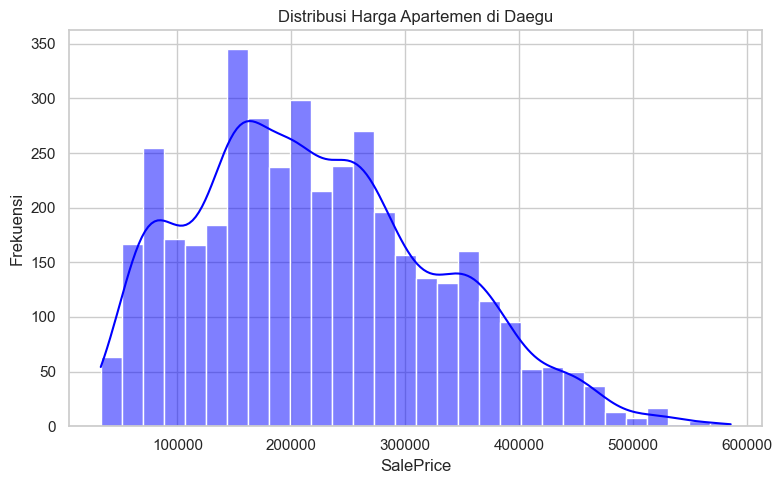

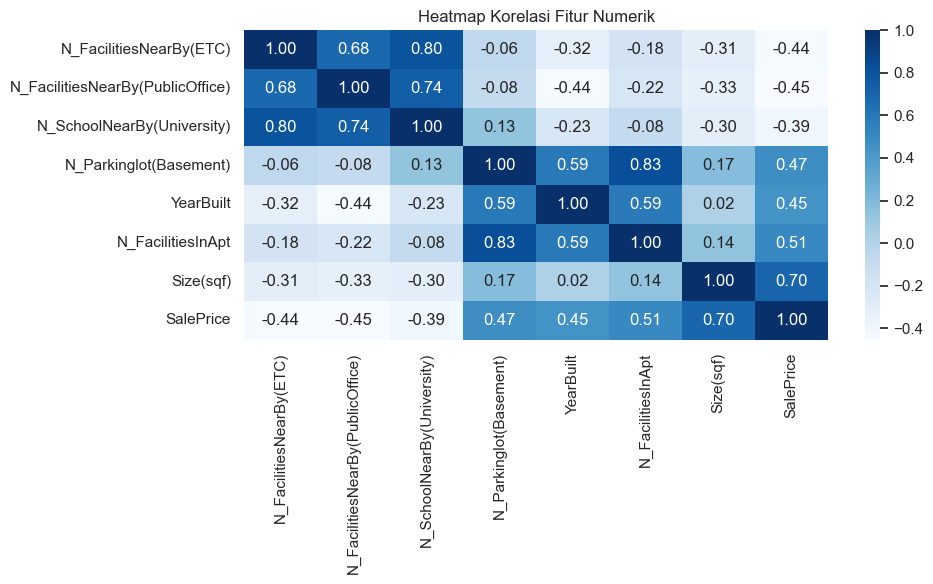

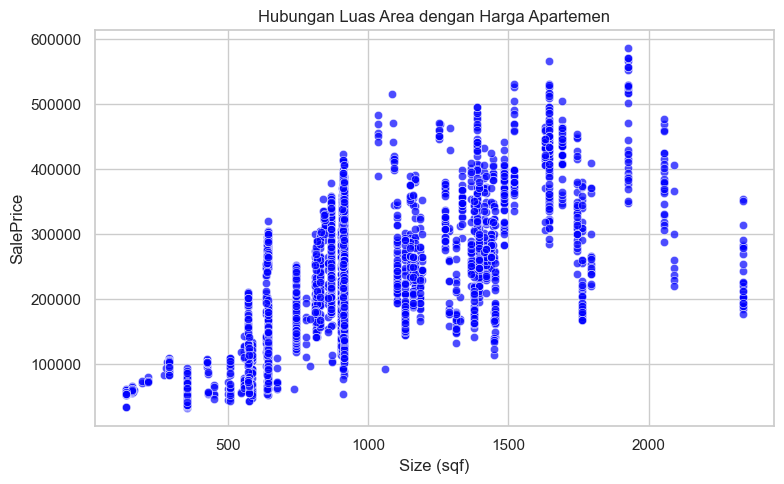

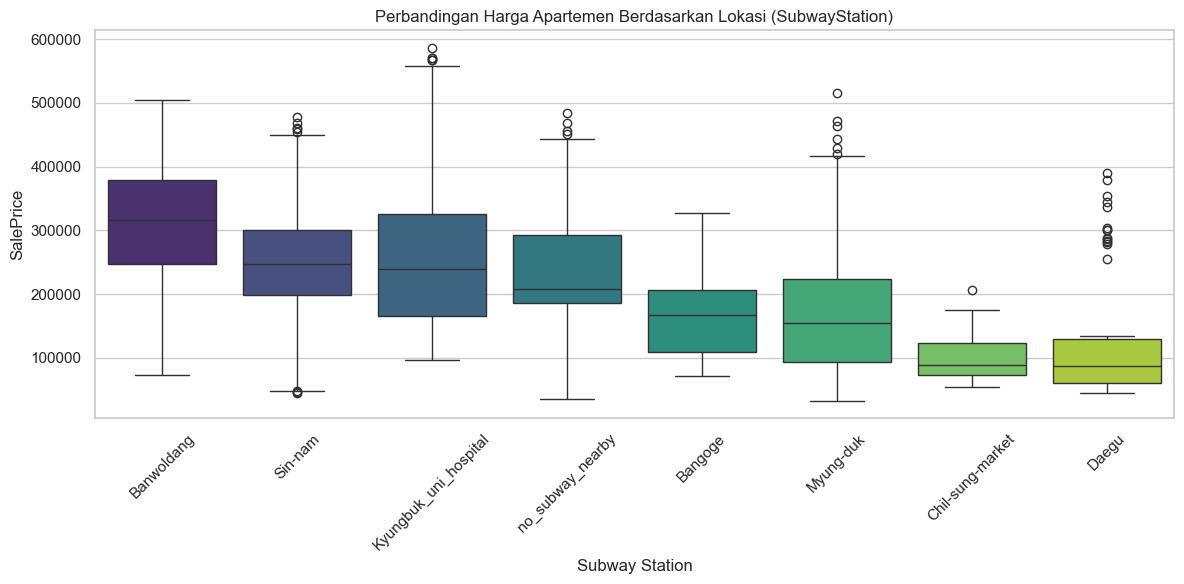

✅ Semua visualisasi EDA berhasil dibuat di folder 'results/'


In [212]:
# Exploratory Data Analysis (EDA)
os.makedirs("results", exist_ok=True)

# --- Kolom penting ---
col_price = "SalePrice"
col_area = "Size(sqf)"
col_station = "SubwayStation"

print(f"Kolom digunakan: Harga = {col_price}, Area = {col_area}, Lokasi = {col_station}")

# --- Distribusi Harga ---
plt.figure(figsize=(8, 5))
sns.histplot(df[col_price], kde=True, bins=30, color='blue')
plt.title('Distribusi Harga Apartemen di Daegu')
plt.xlabel('SalePrice')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.savefig("results/distribusi_harga_apartemen.png")
plt.show()
plt.close()

# --- Korelasi antar fitur numerik ---
plt.figure(figsize=(10, 6))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.savefig("results/heatmap_korelasi_fitur.png")
plt.show()
plt.close()

# --- Hubungan Area vs Harga ---
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df[col_area], y=df[col_price], alpha=0.7, color='blue')
plt.title('Hubungan Luas Area dengan Harga Apartemen')
plt.xlabel('Size (sqf)')
plt.ylabel('SalePrice')
plt.tight_layout()
plt.savefig("results/scatter_area_vs_price.png")
plt.show()
plt.close()

# --- Perbandingan Harga berdasarkan SubwayStation ---
plt.figure(figsize=(12, 6))
order = df.groupby(col_station)[col_price].median().sort_values(ascending=False).index
sns.boxplot(x=col_station, y=col_price, data=df, order=order, palette='viridis')
plt.title('Perbandingan Harga Apartemen Berdasarkan Lokasi (SubwayStation)')
plt.xlabel('Subway Station')
plt.ylabel('SalePrice')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("results/boxplot_harga_per_subwaystation.png")
plt.show()
plt.close()

print("✅ Semua visualisasi EDA berhasil dibuat di folder 'results/'")

### **3. Data Preprocessing**

In [213]:
# 1. Definisikan X (fitur) dan y (target)
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# 2. Split data training dan testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print(f"Ukuran y_train: {y_train.shape}")
print(f"Ukuran y_test: {y_test.shape}")

Ukuran X_train: (3298, 10)
Ukuran X_test: (825, 10)
Ukuran y_train: (3298,)
Ukuran y_test: (825,)


In [214]:
# 3. Buat pipeline preprocessing

# Definisikan kolom numerik dan kategorikal
numerical_features = ['N_FacilitiesNearBy(ETC)', 'N_FacilitiesNearBy(PublicOffice)',
                      'N_SchoolNearBy(University)', 'N_Parkinglot(Basement)', 'YearBuilt',
                      'N_FacilitiesInApt', 'Size(sqf)']

categorical_features = ['HallwayType', 'TimeToSubway', 'SubwayStation']

# Pipeline untuk fitur numerik: Scaling
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pipeline untuk fitur kategorikal: One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Gabungkan kedua pipeline dengan ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ], remainder='drop')

print('Preprocessor siap.')

Preprocessor siap.


### **4. Modeling**

Kita akan mencoba 3 algoritma regresi:
1.  **Linear Regression**: Sebagai *baseline* model yang sederhana.
2.  **Random Forest Regressor**: Model *ensemble* (bagging) yang kuat dan tahan *overfitting*.
3.  **XGBoost Regressor / HistGradientBoostingRegressor**: Model *ensemble* (boosting) yang seringkali memberikan performa terbaik.

In [215]:
# Buat pipeline lengkap (preprocessing + model)

# 1. Linear Regression Pipeline
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# 2. Random Forest Pipeline
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_estimators=100))
])

# 3. XGBoost Pipeline (jika xgboost tidak tersedia, pakai HistGradientBoostingRegressor sebagai fallback)
if XGB_AVAILABLE:
    xgb_reg = xgb.XGBRegressor(random_state=42, n_estimators=100, verbosity=0)
else:
    xgb_reg = HistGradientBoostingRegressor(random_state=42, max_iter=100)

pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_reg)
])

print('Pipelines dibuat: Linear, RandomForest, XGBoost/HistGB (fallback).')

Pipelines dibuat: Linear, RandomForest, XGBoost/HistGB (fallback).


In [216]:
# Latih semua model
print("Melatih Linear Regression...")
pipeline_lr.fit(X_train, y_train)

print("Melatih Random Forest...")
pipeline_rf.fit(X_train, y_train)

print("Melatih XGBoost/HistGB...")
pipeline_xgb.fit(X_train, y_train)

print("Pelatihan selesai.")

Melatih Linear Regression...
Melatih Random Forest...
Melatih XGBoost/HistGB...
Pelatihan selesai.


### **5. Model Evaluation**

In [217]:
# Buat fungsi untuk evaluasi
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# Evaluasi semua model
results_lr = evaluate_model(pipeline_lr, X_test, y_test)
results_rf = evaluate_model(pipeline_rf, X_test, y_test)
results_xgb = evaluate_model(pipeline_xgb, X_test, y_test)

# Tampilkan dalam DataFrame
results_df = pd.DataFrame({
    'Linear Regression': results_lr,
    'Random Forest': results_rf,
    'XGBoost/HistGB': results_xgb
}).T

# Format untuk keterbacaan
results_df_formatted = results_df.copy()
results_df_formatted['MAE'] = results_df_formatted['MAE'].map('{:,.0f}'.format)
results_df_formatted['RMSE'] = results_df_formatted['RMSE'].map('{:,.0f}'.format)
results_df_formatted['R2'] = results_df_formatted['R2'].map('{:.2%}'.format)
results_df_formatted['MAPE'] = results_df_formatted['MAPE'].map('{:.2%}'.format)

print("Hasil Evaluasi Model pada Data Test:")
results_df_formatted # Tampilkan tabel hasil yang diformat

Hasil Evaluasi Model pada Data Test:


,MAE,RMSE,R2,MAPE
Linear Regression,"40,571","50,698",76.17%,23.07%
Random Forest,"32,185","41,074",84.36%,17.83%
XGBoost/HistGB,"32,208","41,125",84.32%,17.80%


### Analisis Performa Model

- **Linear Regression** memiliki performa paling rendah dengan R² **76.17%** dan MAPE **23.07%**.

- **Random Forest** menunjukkan performa terbaik dengan R² **84.36%**, MAE **32,185**, RMSE **41,074**, dan MAPE **17.83%**, mengungguli model lain di 3 dari 4 metrik utama.

- **XGBoost/HistGradientBoosting** memiliki hasil hampir identik (R² **84.32%**, MAPE **17.80%**) dan sedikit lebih baik pada MAPE, namun sedikit kalah pada MAE dan RMSE.

Meskipun perbedaannya tipis, **Random Forest** menjadi pilihan terbaik secara keseluruhan untuk prediksi harga apartemen Daegu karena unggul di sebagian besar metrik dan dikenal robust.

#### **Visualisasi Hasil Model Terbaik (Random Forest)**

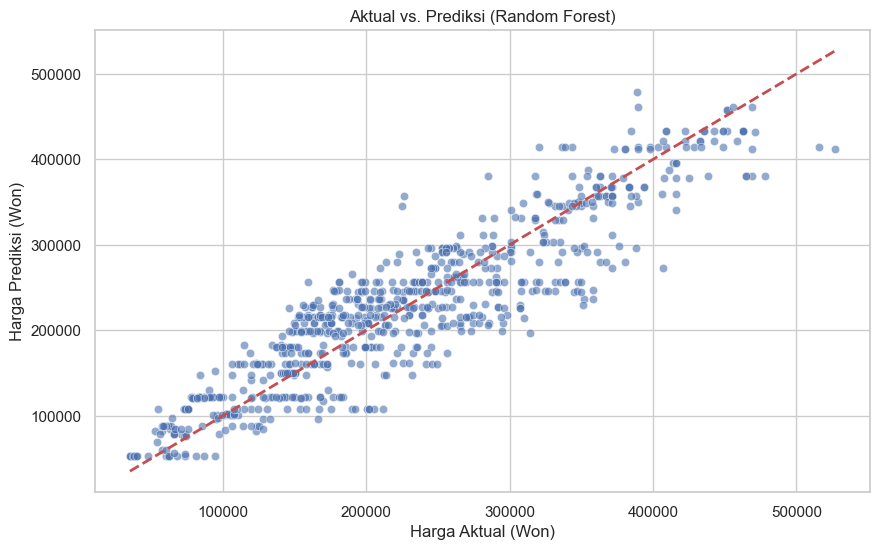

In [218]:
# Plot Aktual vs. Prediksi (Model Random Forest)
y_pred_rf = pipeline_rf.predict(X_test)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Garis ideal
plt.title('Aktual vs. Prediksi (Random Forest)')
plt.xlabel('Harga Aktual (Won)')
plt.ylabel('Harga Prediksi (Won)')
plt.savefig("results/prediction_vs_actual.png")
plt.show()
plt.close()

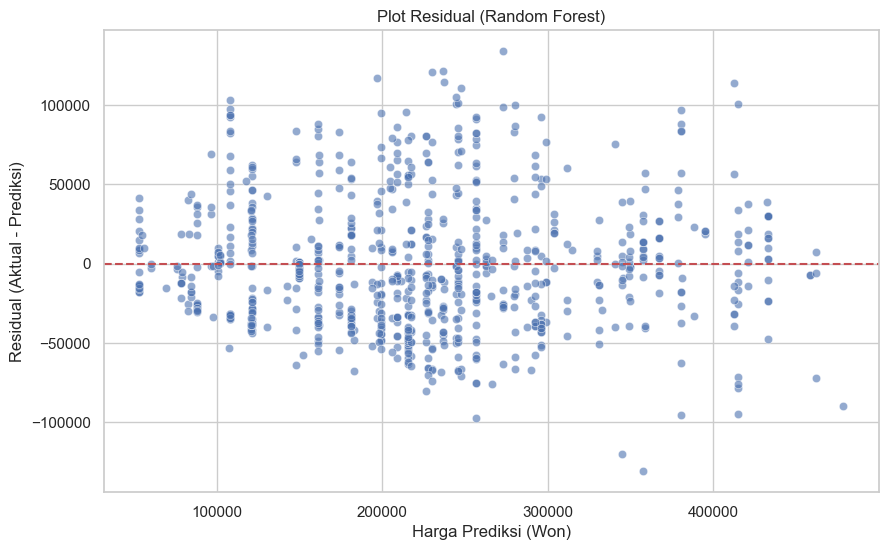

In [219]:
# Plot Residual (Model Random Forest)
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_rf, y=residuals_rf, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Plot Residual (Random Forest)')
plt.xlabel('Harga Prediksi (Won)')
plt.ylabel('Residual (Aktual - Prediksi)')
plt.savefig("results/residual_distribution.png")
plt.show()
plt.close()

Plot residual yang baik seharusnya tersebar acak di sekitar garis nol tanpa pola yang jelas. Di sini, polanya terlihat cukup acak (homoskedastisitas), yang merupakan pertanda baik.

### **6. Penjelasan Algoritma & Metrik (Pencapaian)**

#### **a. Penjelasan Algoritma (Random Forest)**

Model terbaik kita adalah **Random Forest Regressor**, sebuah algoritma *ensemble learning* berbasis *bagging* (Bootstrap Aggregating).

**Cara Kerjanya:**

1.  **Ensemble:** Random Forest tidak hanya membangun satu pohon keputusan, tetapi membangun *banyak* pohon keputusan independen (dalam kasus kita `n_estimators=100`).
2.  **Bagging (Bootstrap Aggregating):**
    * **Bootstrap:** Untuk setiap pohon yang akan dibuat, Random Forest mengambil sampel acak *dengan penggantian* (bootstrap sample) dari data training. Artinya, beberapa data mungkin terpilih lebih dari sekali, sementara yang lain mungkin tidak terpilih sama sekali untuk pohon tersebut.
    * **Random Feature Selection:** Saat membangun setiap pohon, di setiap *split* (pemisahan data), Random Forest tidak mempertimbangkan semua fitur, tetapi hanya memilih subset acak dari fitur untuk dicari *split* terbaiknya. Ini meningkatkan keragaman antar pohon.
3.  **Aggregating (Averaging):** Setelah 100 pohon independen dibangun, untuk membuat prediksi harga pada data baru:
    * Setiap pohon memberikan prediksinya sendiri.
    * Prediksi akhir dari Random Forest adalah **rata-rata** dari prediksi semua pohon individu tersebut.

**Analogi:** Bayangkan Anda ingin memprediksi harga rumah dan bertanya kepada 100 ahli properti (Pohon Keputusan). Namun, Anda tidak memberikan semua informasi yang sama kepada setiap ahli. Setiap ahli hanya melihat sebagian data rumah yang dijual (Bootstrap) dan hanya mempertimbangkan beberapa faktor acak (Random Feature) saat menilai. Setelah semua ahli memberikan estimasi harga mereka, Anda mengambil **rata-rata** dari semua estimasi tersebut sebagai prediksi akhir. Pengambilan rata-rata ini cenderung mengurangi *noise* dan membuat prediksi lebih stabil dan akurat daripada hanya mengandalkan satu ahli saja.

#### **b. Penjelasan Evaluation Metrics**

Kita menggunakan 4 metrik untuk mengevaluasi model regresi kita:

1.  **MAE (Mean Absolute Error)**
    * **Cara Kerja:** Rata-rata *selisih absolut* antara harga aktual dan prediksi.
    * **Hasil RF:** 32,185 Won (rata-rata meleset sebesar ini).

2.  **RMSE (Root Mean Squared Error)**
    * **Cara Kerja:** Akar dari rata-rata *kuadrat* selisih. Lebih sensitif terhadap kesalahan besar.
    * **Hasil RF:** 41,074 Won.

3.  **R-squared (R²)**
    * **Cara Kerja:** Persentase *variasi* harga yang dapat **dijelaskan** oleh model.
    * **Hasil RF:** 84.36% (model menjelaskan 84.36% variasi harga).

4.  **MAPE (Mean Absolute Percentage Error)**
    * **Cara Kerja:** Rata-rata *persentase* selisih absolut terhadap harga aktual.
    * **Hasil RF:** 17.83% (rata-rata meleset 17.83% dari harga sebenarnya).

---


#### **c. Pemilihan Metrik dan Hubungan Bisnis**

**Metrik Pilihan Utama untuk Bisnis: MAPE (Mean Absolute Percentage Error)**

**Alasan Pemilihan:**

1.  **Mudah Dipahami (Interpretability):** Mengatakan "model kami rata-rata meleset 17.83%" lebih mudah dipahami stakeholder.

2.  **Keadilan Relatif:** Persentase kesalahan memberikan gambaran proporsional yang lebih adil.

**Hubungan dengan Aspek Bisnis:**

Target bisnis adalah *rekomendasi harga* yang wajar. **MAPE** mengukur *kewajaran* dalam persentase.

-   Dengan **MAPE 17.83%**, tingkat akurasi rata-rata sekitar 82% (100% - 17.83%).
-   Membantu penjual menetapkan ekspektasi realistis, mempercepat penjualan.

#### **d. Limitasi Model (Kapan Percaya, Kapan Tidak)**

Model ini, meskipun performanya baik (R² ~84%), memiliki batasan.

**Kapan Model Dapat Dipercaya (Akurat):**

1.  **Untuk Properti "Rata-rata" / Umum:** Akurat untuk apartemen yang karakteristiknya mirip mayoritas data latih.
2.  **Kondisi Pasar Stabil:** Akurasi tertinggi jika kondisi pasar saat prediksi mirip saat data latih dikumpulkan.
3.  **Sebagai Alat Bantu (Guideline):** Baik sebagai *starting point* atau *benchmark* harga.


**Kapan Model TIDAK Dapat Dipercaya (Kurang Akurat):**

1.  **Properti Unik / *Outlier*:** Kesulitan memprediksi properti yang sangat berbeda.
2.  **Saat Terjadi Guncangan Pasar (Market Shocks):** Tidak bisa memprediksi dampak kejadian eksternal.
3.  **Data yang Tidak Tercakup (Missing Features):** Tidak mempertimbangkan kondisi interior, lantai, pemandangan, dll.


### **7. Conclusion & Recommendation**

#### **Conclusion**

1.  Model *machine learning* regresi telah berhasil dibangun untuk memprediksi harga apartemen di Daegu.
2.  Model terbaik adalah **Random Forest Regressor** yang mencapai performa **R-squared 84.36%** dan **MAPE 17.83%** pada data uji.
3.  Model mampu menjelaskan mayoritas variasi harga berdasarkan fitur yang ada, dengan tingkat kesalahan prediksi rata-rata sekitar 17.8%. Fitur seperti `Size(sqf)`, `YearBuilt`, dan `SubwayStation` terbukti menjadi prediktor penting.


#### **Proposed Solution (Measurable)**

Implementasi model sebagai fitur **"Smart Price Recommendation"** di platform listing properti.

1.  **Untuk Penjual:** Saat listing, model menampilkan "Rekomendasi Harga Pasar: ₩XXX,XXX".
2.  **Goal:** Membantu penjual menetapkan harga kompetitif dalam rentang **±18% (MAPE)** dari harga wajar pasar.
3.  **Metric Keberhasilan (Measurable):**
    * **Bisnis:** Peningkatan **Time-to-Sell**. Hipotesis: Apartemen dengan harga sesuai rekomendasi (±10%) akan **terjual 20% lebih cepat**.
    * **Produk:** Peningkatan **Listing Conversion Rate**. Hipotesis: Persentase penyelesaian listing **meningkat 15%** karena kepercayaan harga.


#### **Recommendation & Business Impact**

**Rekomendasi Penggunaan:**
-   Gunakan sebagai **pedoman**, bukan harga mutlak.
-   **Latih ulang (Retrain)** secara berkala (3-6 bulan).
-   Berikan **peringatan** untuk properti unik/outlier.

**Dampak Implementasi (Measurable):**
-   **Penjual/Agen:** Mengurangi riset, mempercepat penjualan, memaksimalkan profit.
-   **Platform:** Meningkatkan *trust* & *engagement*, menjadi USP.
-   **Pembeli:** Memberikan transparansi & *benchmark* harga.


#### **Limitations & Future Improvements**

**Batasan Proyek:**
1.  **Batasan Data (Fitur):** Tidak ada fitur kondisi interior, lantai, pemandangan, data makro-ekonomi.
2.  **Batasan Model (Statis):** Tidak belajar secara *real-time*.
3.  **Batasan Waktu/Scope:** Belum mencakup *Hyperparameter Tuning* mendalam atau *deployment*.

**Rekomendasi Selanjutnya (Future Improvements):**
1.  **Data Enrichment:** Tambah fitur lantai, gunakan NLP & Computer Vision.
2.  **Implementasi MLOps:** Bangun *pipeline* MLOps untuk *retraining* & *monitoring* otomatis.
3.  **Hyperparameter Tuning:** Gunakan GridSearchCV/Optuna pada Random Forest.


### **8. Save Model Terbaik (Random Forest)**

In [220]:
# Kita akan menyimpan model terbaik kita, yaitu pipeline_rf (Random Forest)

# Definisikan estimator/pipeline yang ingin disimpan
estimator = pipeline_rf # Menggunakan pipeline Random Forest

# Latih ulang model dengan semua data (best practice)
print("Melatih model final (Random Forest) dengan semua data...")
estimator.fit(X, y)
print("Pelatihan model final selesai.")

# Prediksi dan evaluasi pada SEMUA data (sebagai sanity check setelah retrain)
y_pred_full = estimator.predict(X)
mae_full = mean_absolute_error(y, y_pred_full)
rmse_full = root_mean_squared_error(y, y_pred_full)
r2_full = r2_score(y, y_pred_full)
mape_full = mean_absolute_percentage_error(y, y_pred_full)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Simpan hasil evaluasi ke file txt
txt_path = f"results/model_evaluation.txt"
with open(txt_path, "w") as f:
    f.write("=== Model Evaluation on Full Data (Daegu Apartment) ===\n")
    f.write(f"Timestamp : {timestamp}\n")
    f.write(f"Model Type: RandomForestRegressor\n")
    f.write(f"MAE  : {mae_full:,.2f}\n")
    f.write(f"RMSE : {rmse_full:,.2f}\n")
    f.write(f"R²   : {r2_full:.4f}\n")
    f.write(f"MAPE : {mape_full:.2%}\n")
print(f"Hasil evaluasi (pada data penuh) disimpan di {txt_path}")

# Simpan model ke file .pkl
model_filename = 'Model_Daegu_Apartment.pkl'
pickle.dump(estimator, open(model_filename, 'wb'))
print(f"✅ Model telah disimpan ke '{model_filename}'")

Melatih model final (Random Forest) dengan semua data...
Pelatihan model final selesai.
Hasil evaluasi (pada data penuh) disimpan di results/model_evaluation.txt
✅ Model telah disimpan ke 'Model_Daegu_Apartment.pkl'


In [ ]:
# Load model
filename = 'Model_Daegu_Apartment.pkl'
loaded_model = pickle.load(open(filename, 'rb'))

print("✅ Model berhasil di-load")

✅ Model berhasil di-load


In [223]:
# Lakukan prediksi pada data test sebagai contoh
# Gunakan X_test dan y_test
contoh_data = X_test.iloc[0:1]
harga_aktual = y_test.iloc[0]

print("Data yang akan diprediksi:")
display(contoh_data)

# Lakukan prediksi
prediksi_harga = loaded_model.predict(contoh_data)

print(f"Harga Aktual: {harga_aktual:,.0f} Won")
print(f"Harga Prediksi Model: {prediksi_harga[0]:,.0f} Won")

Data yang akan diprediksi:


,HallwayType,TimeToSubway,SubwayStation,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf)
1618,terraced,0-5min,Kyungbuk_uni_hospital,0.0,5.0,3.0,930.0,2013,7,910


Harga Aktual: 255,442 Won
Harga Prediksi Model: 293,416 Won
